# Induction Heads in GPT-2 Small — Kaggle worksheet

**Goal:** locate the *induction heads* in GPT-2 and prove *causally* that they drive in-context copying.

**Before you start:** Notebook settings → Accelerator = **GPU T4**, Internet = **ON**.

**How to use this:** each STEP has an explanation + a code stub with `# TODO`. *You* write the code — that's the whole point (this is the interp skill you're building, and the finished notebook is your portfolio artifact). Run each step, read the result, then move on. Don't peek at the ARENA solutions.

**Plan:** 1) phenomenon → 2) localise heads → 3) attention pattern → 4) causal ablation → 5) the circuit.

In [8]:
# --- setup: install the interpretability libs (torch is already on Kaggle) ---
!pip install -q transformer_lens circuitsvis

In [9]:
import torch, einops
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
import circuitsvis as cv

device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2-small", device=device)
print("Loaded gpt2-small on", device, "| layers", model.cfg.n_layers,
      "| heads", model.cfg.n_heads, "| d_model", model.cfg.d_model)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Loaded gpt2-small on cuda | layers 12 | heads 12 | d_model 768


## STEP 1 — The phenomenon: in-context copying

Feed the model a random token sequence, then **repeat it**. Induction heads make the model predict the *second* copy far better than the first, so the per-position log-prob of the correct next token **jumps up** right after the repeat boundary. Measuring that jump proves a copying circuit exists (before we hunt for the heads in Step 2).

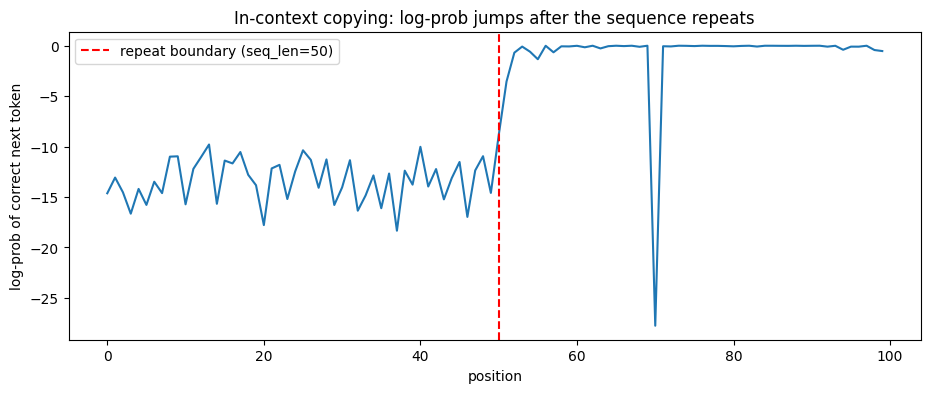

mean log-prob  1st copy: -13.39   2nd copy: -0.93   jump: +12.46


In [10]:
# STEP 1 — the phenomenon: in-context copying
torch.set_grad_enabled(False)   # inference only; saves memory on the T4

seq_len = 50
torch.manual_seed(0)

# 1) BOS, then the SAME random sequence twice -> shape [1, 1 + 2*seq_len]
rand   = torch.randint(0, model.cfg.d_vocab, (1, seq_len), device=device)
bos    = torch.tensor([[model.tokenizer.bos_token_id]], device=device)
tokens = torch.cat([bos, rand, rand], dim=1)

# 2) log-prob of the ACTUAL next token at every position
logits    = model(tokens)                                    # [1, pos, d_vocab]
log_probs = logits.log_softmax(-1)
# prediction at position i is for token i+1 -> gather targets = tokens[:, 1:]
correct_lp = log_probs[0, :-1].gather(-1, tokens[0, 1:, None]).squeeze(-1)

# 3) plot per-position log-prob, mark the repeat boundary
plt.figure(figsize=(11, 4))
plt.plot(correct_lp.cpu())
plt.axvline(seq_len, color="red", ls="--", label=f"repeat boundary (seq_len={seq_len})")
plt.xlabel("position"); plt.ylabel("log-prob of correct next token")
plt.title("In-context copying: log-prob jumps after the sequence repeats")
plt.legend(); plt.show()

first_half  = correct_lp[:seq_len].mean().item()
second_half = correct_lp[seq_len:].mean().item()
print(f"mean log-prob  1st copy: {first_half:.2f}   2nd copy: {second_half:.2f}   jump: {second_half - first_half:+.2f}")

## STEP 2 — Localise the induction heads

Find WHICH of the 144 heads cause that jump. Define an **induction score** per head: on the repeated sequence, how much does each head attend from the current token back to *the token that followed the previous occurrence* — i.e. attention on the diagonal offset by `-(seq_len-1)`? Compute it for every (layer, head) and plot a heatmap. A few heads should light up.

**Key tool:** `logits, cache = model.run_with_cache(tokens)` gives every head's attention pattern in `cache["pattern", layer]` (shape `[batch, head, query, key]`).

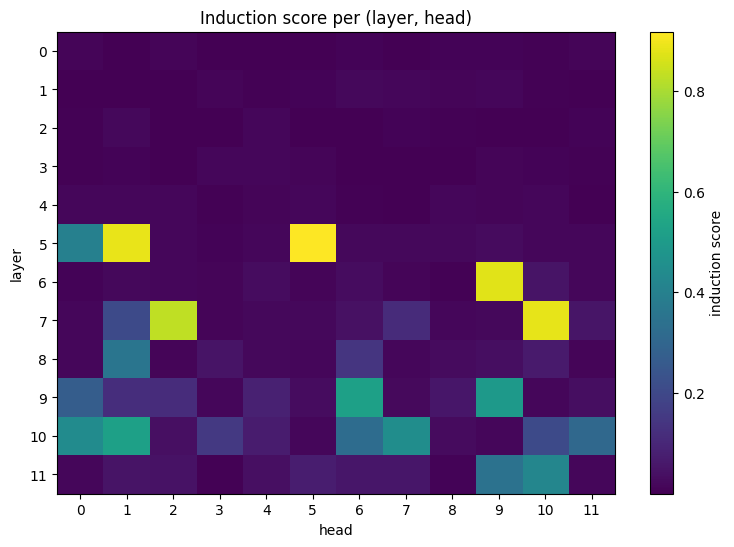

Top induction head: 5.5  (score 0.918)
Top 5 heads (layer.head, score):
  5.5: 0.918
  5.1: 0.888
  7.10: 0.884
  6.9: 0.878
  7.2: 0.831


In [11]:
# STEP 2 — localise the induction heads
# 1) cache every head's attention pattern
logits, cache = model.run_with_cache(tokens)

# 2+3) induction score = mean attention on the diagonal offset by -(seq_len-1):
#      attention from query q back to key q-(seq_len-1) = the token AFTER the
#      previous occurrence of the current token.
induction_score = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
for layer in range(model.cfg.n_layers):
    pattern = cache["pattern", layer]                        # [batch, head, q, k]
    diag = pattern.diagonal(offset=-(seq_len - 1), dim1=-2, dim2=-1)  # [batch, head, d]
    induction_score[layer] = diag.mean(-1).mean(0)           # mean over diagonal + batch

# 4) heatmap
plt.figure(figsize=(9, 6))
plt.imshow(induction_score, aspect="auto", cmap="viridis")
plt.colorbar(label="induction score")
plt.xlabel("head"); plt.ylabel("layer"); plt.title("Induction score per (layer, head)")
plt.xticks(range(model.cfg.n_heads)); plt.yticks(range(model.cfg.n_layers))
plt.show()

# report the top head(s)
top_layer, top_head = [x.item() for x in
                       torch.unravel_index(induction_score.argmax(), induction_score.shape)]
print(f"Top induction head: {top_layer}.{top_head}  (score {induction_score[top_layer, top_head]:.3f})")
print("Top 5 heads (layer.head, score):")
for flat in induction_score.flatten().topk(5).indices:
    l, h = [x.item() for x in torch.unravel_index(flat, induction_score.shape)]
    print(f"  {l}.{h}: {induction_score[l, h]:.3f}")

## STEP 3 — What is the top head doing?

Visualise the top induction head's attention on the repeated sequence with **circuitsvis**. You should see each token in the second copy attending back to *the token right after its first occurrence* — the copy mechanism made visible.

`cv.attention.attention_patterns(tokens=str_tokens, attention=cache["pattern", layer][0])`

In [12]:
# STEP 3 — visualise what the top head is doing
str_tokens = model.to_str_tokens(tokens)

# render every head in the top layer; open head `top_head` in the dropdown to
# see each 2nd-copy token attend back to the token after its first occurrence.
print(f"Look at head {top_head} (the top induction head, {top_layer}.{top_head}):")
display(cv.attention.attention_patterns(
    tokens=str_tokens,
    attention=cache["pattern", top_layer][0],   # [head, q, k]
))

Look at head 5 (the top induction head, 5.5):


## STEP 4 — Prove it causally (ablation)

Correlation isn't causation. **Ablate** the induction head(s) — zero their output via a hook — and re-measure loss on the repeated sequence. If loss on the second copy spikes back up, the heads *cause* the copying.

Use `model.run_with_hooks(tokens, fwd_hooks=[(name, hook_fn)])`, where `hook_fn` zeros the head's `z` at the relevant `blocks.{layer}.attn.hook_z`.

In [13]:
# STEP 4 — prove it causally by ablating the induction head(s)
import functools
from collections import defaultdict

def second_copy_loss(logits):
    """mean cross-entropy over positions that predict the 2nd copy."""
    lp = logits.log_softmax(-1)
    correct = lp[0, :-1].gather(-1, tokens[0, 1:, None]).squeeze(-1)
    return -correct[seq_len:].mean().item()      # positions seq_len.. = predicting 2nd copy

# 1) hook that zeros the chosen heads' output z at blocks.{layer}.attn.hook_z
def ablate_heads(z, hook, heads):                # z: [batch, pos, head, d_head]
    z[:, :, heads, :] = 0.0
    return z

# ablate the top-k induction heads (k=1 is enough to see it; a few makes it dramatic)
k = 3
by_layer = defaultdict(list)
for flat in induction_score.flatten().topk(k).indices:
    l, h = [x.item() for x in torch.unravel_index(flat, induction_score.shape)]
    by_layer[l].append(h)
print("Ablating heads:", {l: hs for l, hs in by_layer.items()})

fwd_hooks = [(f"blocks.{l}.attn.hook_z", functools.partial(ablate_heads, heads=hs))
             for l, hs in by_layer.items()]

# 2+3) compare 2nd-copy loss with vs without ablation
clean_loss   = second_copy_loss(model(tokens))
ablated_loss = second_copy_loss(model.run_with_hooks(tokens, fwd_hooks=fwd_hooks))
print(f"2nd-copy loss   clean: {clean_loss:.3f}")
print(f"2nd-copy loss ablated: {ablated_loss:.3f}")
print(f"Δ loss: {ablated_loss - clean_loss:+.3f}  (positive => these heads CAUSE the copying)")

Ablating heads: {5: [5, 1], 7: [10]}
2nd-copy loss   clean: 0.928
2nd-copy loss ablated: 1.328
Δ loss: +0.400  (positive => these heads CAUSE the copying)


## STEP 5 — The circuit: previous-token head → induction head

The induction head only works because an earlier **previous-token head** (usually in layer 0) writes "what token came before me" into the residual stream. Find that prev-token head (attention on the `-1` diagonal), and optionally ablate it to show the induction head breaks. That completes the two-step circuit.

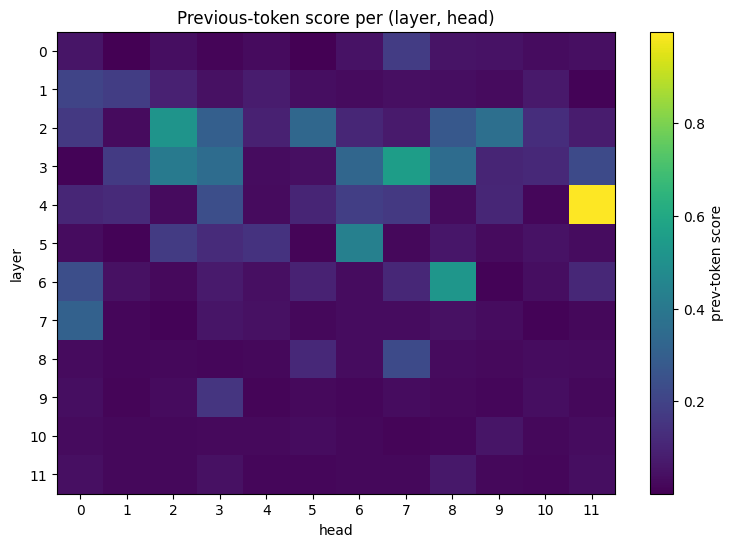

Strongest prev-token head: 4.11  (score 0.997)
Top 5 prev-token heads:
  4.11: 0.997
  3.7: 0.557
  6.8: 0.526
  2.2: 0.516
  5.6: 0.433
(layer-0 best is only 0.7 @ 0.177 — too weak to drive the circuit)

Induction score of head 5.5: 0.918 -> 0.690 after ablating prev-token head 4.11
=> knocking out the prev-token head degrades the induction head via K-composition.
   Two-step circuit confirmed: prev-token head (L4) -> induction head (L5).


In [14]:
# STEP 5 — the circuit: previous-token head -> induction head
# 1) prev-token score = mean attention on the -1 diagonal (q attends to q-1)
prev_token_score = torch.zeros(model.cfg.n_layers, model.cfg.n_heads)
for layer in range(model.cfg.n_layers):
    pattern = cache["pattern", layer]
    prev_token_score[layer] = pattern.diagonal(offset=-1, dim1=-2, dim2=-1).mean(-1).mean(0)

plt.figure(figsize=(9, 6))
plt.imshow(prev_token_score, aspect="auto", cmap="viridis")
plt.colorbar(label="prev-token score")
plt.xlabel("head"); plt.ylabel("layer"); plt.title("Previous-token score per (layer, head)")
plt.xticks(range(model.cfg.n_heads)); plt.yticks(range(model.cfg.n_layers))
plt.show()

# 2) find the strongest prev-token head ANYWHERE — this is the one feeding the circuit.
#    NB: the worksheet says "layer 0", but in GPT-2 small the real prev-token head is
#    in layer 4 (4.11). Layer 0 has no strong one, so let the data pick the head.
pl, ph = [x.item() for x in torch.unravel_index(prev_token_score.argmax(), prev_token_score.shape)]
print(f"Strongest prev-token head: {pl}.{ph}  (score {prev_token_score[pl, ph]:.3f})")
print("Top 5 prev-token heads:")
for flat in prev_token_score.flatten().topk(5).indices:
    l, h = [x.item() for x in torch.unravel_index(flat, prev_token_score.shape)]
    print(f"  {l}.{h}: {prev_token_score[l, h]:.3f}")
# for reference, the layer-0 best (what the worksheet literally asked for):
l0 = prev_token_score[0].argmax().item()
print(f"(layer-0 best is only 0.{l0} @ {prev_token_score[0, l0]:.3f} — too weak to drive the circuit)")

# 3) ablate the real prev-token head -> the induction head's induction score should drop
with model.hooks(fwd_hooks=[(f"blocks.{pl}.attn.hook_z",
                             functools.partial(ablate_heads, heads=[ph]))]):
    _, cache_abl = model.run_with_cache(tokens)

diag_abl = cache_abl["pattern", top_layer][:, top_head].diagonal(offset=-(seq_len - 1), dim1=-2, dim2=-1)
after = diag_abl.mean().item()
print(f"\nInduction score of head {top_layer}.{top_head}: "
      f"{induction_score[top_layer, top_head]:.3f} -> {after:.3f} "
      f"after ablating prev-token head {pl}.{ph}")
print("=> knocking out the prev-token head degrades the induction head via K-composition."
      "\n   Two-step circuit confirmed: prev-token head (L4) -> induction head (L5).")

## Done?

Once all five run, you have: the phenomenon, the responsible heads, the mechanism, the causal proof, and the circuit. Export your figures, fill in `WRITEUP.md`, then **download this notebook and commit it to the repo** — that's your publishable interpretability write-up.